# Compas Analysis

What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

In [1]:
# Python setup
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.metrics import confusion_matrix

pd.set_option('display.max_columns', None)


In [2]:
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)
raw_data.shape[0]

7214

In [3]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.0,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.0,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.0,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.0,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.0,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.0,F,Possession of Cocaine,1,13011511MM10A,(M1),0.0,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.0,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.0,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,0,1,0,0,0,0.0,2013-11-30 04:50:18,2013-12-01 12:28:56,13022355MM10A,2013-11-30,NaN,0.0,M,Battery,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-11-30,Risk of Violence,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,0,6,0,0,14,-1.0,2014-02-18 05:08:24,2014-02-24 12:18:30,14002304CF10A,2014-02-18,NaN,1.0,F,Possession Burglary Tools,1,14004485CF10A,(F2),0.0,2014-03-31,Poss of Firearm by Convic Felo,2014-03-31,2014-04-18,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,6,Medium,2014-02-19,Risk of Violence,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,0,4,0,0,3,-1.0,2013-08-29 08:55:23,2013-08-30 08:42:13,13012216CF10A,NaN,2013-08-29,1.0,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-08-30,Risk of Violence,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,0,1,0,0,0,-1.0,2014-03-15 05:35:34,2014-03-18 04:28:46,14004524MM10A,2014-03-15,NaN,1.0,M,Battery,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2014-03-16,Risk of Violence,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less

However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [4]:
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

df = raw_data[
    [
        "age", "c_charge_degree", "race", "age_cat", "score_text", "sex",
        "priors_count", "days_b_screening_arrest", "decile_score",
        "is_recid", "two_year_recid", "c_jail_in", "c_jail_out"
    ]
].copy()

# Filtering
df = df[df["days_b_screening_arrest"].between(-30, 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]

# Type conversions
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)

for col in df.columns:
    if col not in numeric_vars + datetime_vars:
        df[col] = df[col].astype("category")

# Derived factors with reference levels
df["crime_factor"] = df["c_charge_degree"].astype("category")

age_order = ["25 - 45", "Greater than 45", "Less than 25"]
df["age_factor"] = pd.Categorical(df["age_cat"], categories=age_order, ordered=False)

race_levels = ["Caucasian"] + [x for x in df["race"].cat.categories if x != "Caucasian"]
df["race_factor"] = pd.Categorical(df["race"], categories=race_levels, ordered=False)

df["gender_factor"] = pd.Categorical(df["sex"], categories=["Male", "Female"], ordered=False)

df["score_factor"] = np.where(df["score_text"] != "Low", "HighScore", "LowScore")
df["score_factor"] = pd.Categorical(df["score_factor"], categories=["LowScore", "HighScore"], ordered=False)

df.shape[0]

6172

In [5]:
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   category           
 2   race                     6172 non-null   category           
 3   age_cat                  6172 non-null   category           
 4   score_text               6172 non-null   category           
 5   sex                      6172 non-null   category           
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   category           
 10  two_year_recid           6172 non-null   category           
 11  c_jail_in                6172 non-n

Higher COMPAS scores are slightly correlated with a longer length of stay.

In [7]:
df["c_jail_in"] = pd.to_datetime(df["c_jail_in"])
df["c_jail_out"] = pd.to_datetime(df["c_jail_out"])

df["length_of_stay"] = (df["c_jail_out"] - df["c_jail_in"]).dt.days
df["length_of_stay"].corr(df["decile_score"])


np.float64(0.20747808478031807)

After filtering we have the following demographic breakdown:

In [8]:
df["age_cat"].value_counts()

,count
age_cat,
25 - 45,3532
Less than 25,1347
Greater than 45,1293


In [9]:
df["race"].value_counts()

,count
race,
African-American,3175
Caucasian,2103
Hispanic,509
Other,343
Asian,31
Native American,11


In [10]:
print("Black defendants: %.2f%%" % (3175 / 6172 * 100))
print("White defendants: %.2f%%" % (2103 / 6172 * 100))
print("Hispanic defendants: %.2f%%" % (509  / 6172 * 100))
print("Asian defendants: %.2f%%" % (31   / 6172 * 100))
print("Native American defendants: %.2f%%" % (11   / 6172 * 100))

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [11]:
df["score_text"].value_counts()

,count
score_text,
Low,3421
Medium,1607
High,1144


In [12]:
pd.crosstab(df["sex"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


In [13]:
df["sex"].value_counts()

,count
sex,
Male,4997
Female,1175


In [14]:
print("Men: %.2f%%" % (4997 / 6172 * 100))
print("Women: %.2f%%" % (1175 / 6172 * 100))

Men: 80.96%
Women: 19.04%


In [15]:
df[df["two_year_recid"] == 1].shape[0]

2809

In [16]:
df[df["two_year_recid"] == 1].shape[0] / df.shape[0] * 100

45.51198963058976

Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

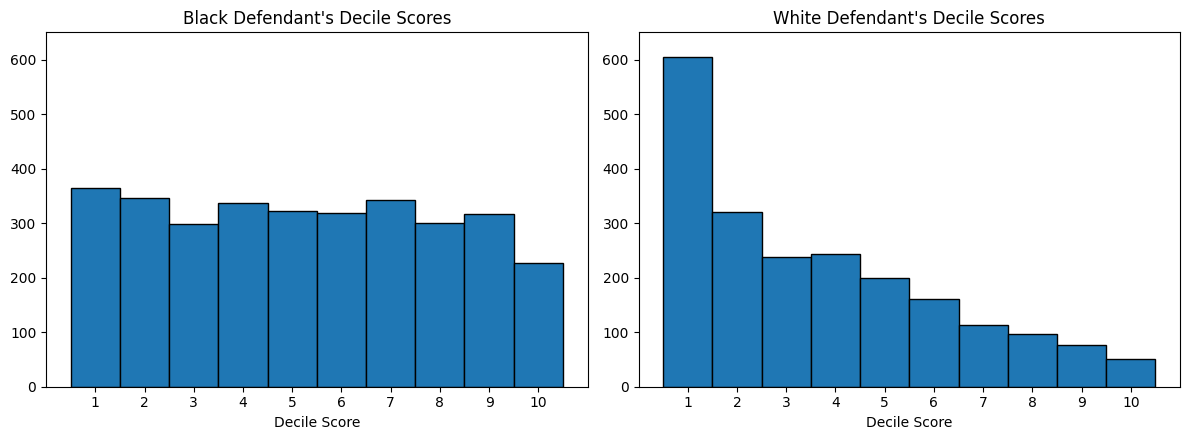

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

black_scores = df.loc[df["race"] == "African-American", "decile_score"]
white_scores = df.loc[df["race"] == "Caucasian", "decile_score"]

axes[0].hist(black_scores, bins=np.arange(0.5, 11.5, 1), edgecolor="black")
axes[0].set_title("Black Defendant's Decile Scores")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylim(0, 650)
axes[0].set_xticks(range(1, 11))

axes[1].hist(white_scores, bins=np.arange(0.5, 11.5, 1), edgecolor="black")
axes[1].set_title("White Defendant's Decile Scores")
axes[1].set_xlabel("Decile Score")
axes[1].set_ylim(0, 650)
axes[1].set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

In [18]:
pd.crosstab(df["decile_score"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into categorical variables, and run a logistic regression, comparing low scores to high scores.

In [19]:
df["score_binary"] = (df["score_factor"] == "HighScore").astype(int)

model_glm = smf.logit(
    "score_binary ~ "
    "C(gender_factor, Treatment(reference=\"Male\")) + "
    "C(age_factor, Treatment(reference=\"25 - 45\")) + "
    "C(race_factor, Treatment(reference=\"Caucasian\")) + "
    "priors_count + "
    "C(crime_factor) + "
    "two_year_recid",
    data=df
).fit(disp=False)

model_glm.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Mon, 06 Apr 2026   Pseudo R-squ.:                  0.2729
Time:                        03:09:45   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
========================================================================================================================================
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                               -1.5255      0.079    -19.430      0.000      -1.679      -1.372
C(gender_factor, Treatment(reference="Male"))[T.Female]                  0.2213      0.080      2.783      0.005       0.065       0.377
C(age_factor, Treatment(reference="25 - 45"))[T.Greater than 45]        -1.3556      0.099    -13.682      0.000      -1.550      -1.161
C(age_factor, Treatment(reference="25 - 45"))[T.Less than 25]            1.3084      0.076     17.232      0.000       1.160       1.457
C(race_factor, Treatment(reference="Caucasian"))[T.African-American]     0.4772      0.069      6.881      0.000       0.341       0.613
C(race_factor, Treatment(reference="Caucasian"))[T.Asian]               -0.2544      0.478     -0.532      0.595      -1.192       0.683
C(race_factor, Treatment(reference="Caucasian"))[T.Hispanic]            -0.4284      0.128     -3.344      0.001      -0.680      -0.177
C(race_factor, Treatment(reference="Caucasian"))[T.Native American]      1.3942      0.766      1.820      0.069      -0.107       2.896
C(race_factor, Treatment(reference="Caucasian"))[T.Other]               -0.8263      0.162     -5.098      0.000      -1.144      -0.509
C(crime_factor)[T.M]                                                    -0.3112      0.067     -4.677      0.000      -0.442      -0.181
two_year_recid[T.1]                                                      0.6859      0.064     10.713      0.000       0.560       0.811
priors_count                                                             0.2689      0.011     24.221      0.000       0.247       0.291
========================================================================================================================================
"""

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [20]:
control = np.exp(-1.52554) / (1 + np.exp(-1.52554))
np.exp(0.47721) / (1 - control + (control * np.exp(0.47721)))

np.float64(1.4528408658138932)

Women are 19.4% more likely than men to get a higher score.

In [21]:
np.exp(0.22127) / (1 - control + (control * np.exp(0.22127)))

np.float64(1.1947978508506671)

Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [22]:
np.exp(1.30839) / (1 - control + (control * np.exp(1.30839)))

np.float64(2.4961202077189455)

In [23]:
df["pred_prob"] = model_glm.predict(df)
df["pred_class"] = np.where(df["pred_prob"] >= 0.5, "Recid", "No Recid")
df["pred_class"] = pd.Categorical(df["pred_class"], categories=["No Recid", "Recid"])

In [24]:
print("\n── Overall Confusion Matrix ──────────────────────────────────────────\n")

overall_cm = pd.crosstab(df["pred_class"], df["two_year_recid"])
print(overall_cm)

TP = overall_cm.loc["Recid", 1]
TN = overall_cm.loc["No Recid", 0]
FP = overall_cm.loc["Recid", 0]
FN = overall_cm.loc["No Recid", 1]
n = overall_cm.to_numpy().sum()

print("\nAccuracy  : %.3f" % ((TP + TN) / n))
print("Precision : %.3f" % (TP / (TP + FP)))
print("Recall    : %.3f" % (TP / (TP + FN)))
print("FPR       : %.3f" % (FP / (FP + TN)))
print("FNR       : %.3f" % (FN / (FN + TP)))


── Overall Confusion Matrix ──────────────────────────────────────────

two_year_recid     0     1
pred_class                
No Recid        2653   945
Recid            710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [25]:
print("\n\n── Confusion Matrix by Race ──────────────────────────────────────────\n")

temp = df.copy()
temp["actual"] = temp["two_year_recid"].astype(int)
temp["pred"] = (temp["pred_class"] == "Recid").astype(int)

race_metrics = temp.groupby("race").apply(
    lambda g: pd.Series({
        "n": len(g),
        "TP": ((g["pred"] == 1) & (g["actual"] == 1)).sum(),
        "TN": ((g["pred"] == 0) & (g["actual"] == 0)).sum(),
        "FP": ((g["pred"] == 1) & (g["actual"] == 0)).sum(),
        "FN": ((g["pred"] == 0) & (g["actual"] == 1)).sum(),
    })
).reset_index()

race_metrics["Accuracy"] = ((race_metrics["TP"] + race_metrics["TN"]) / race_metrics["n"]).round(3)
race_metrics["Precision"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FP"])).round(3)
race_metrics["Recall"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FN"])).round(3)
race_metrics["FPR"] = (race_metrics["FP"] / (race_metrics["FP"] + race_metrics["TN"])).round(3)
race_metrics["FNR"] = (race_metrics["FN"] / (race_metrics["FN"] + race_metrics["TP"])).round(3)

race_metrics = race_metrics.sort_values("n", ascending=False).reset_index(drop=True)
print(race_metrics)



── Confusion Matrix by Race ──────────────────────────────────────────

               race     n    TP    TN   FP   FN  Accuracy  Precision  Recall  \
0  African-American  3175  1373   959  555  288     0.734      0.712   0.827   
1         Caucasian  2103   381  1148  133  441     0.727      0.741   0.464   
2          Hispanic   509    81   306   14  108     0.760      0.853   0.429   
3             Other   343    22   216    3  102     0.694      0.880   0.177   
4             Asian    31     2    22    1    6     0.774      0.667   0.250   
5   Native American    11     5     2    4    0     0.636      0.556   1.000   

     FPR    FNR  
0  0.367  0.173  
1  0.104  0.536  
2  0.044  0.571  
3  0.014  0.823  
4  0.043  0.750  
5  0.667  0.000  


In [26]:
print("\n\n── FPR and FNR Disparity by Race ─────────────────────────────────────\n")

disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()
white_fpr = disparity.loc[disparity["race"] == "Caucasian", "FPR"].iloc[0]
white_fnr = disparity.loc[disparity["race"] == "Caucasian", "FNR"].iloc[0]

disparity["delta_FPR"] = (disparity["FPR"] - white_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - white_fnr).round(3)

print(disparity)



── FPR and FNR Disparity by Race ─────────────────────────────────────

               race     n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175  0.367  0.173      0.263     -0.363
1         Caucasian  2103  0.104  0.536      0.000      0.000
2          Hispanic   509  0.044  0.571     -0.060      0.035
3             Other   343  0.014  0.823     -0.090      0.287
4             Asian    31  0.043  0.750     -0.061      0.214
5   Native American    11  0.667  0.000      0.563     -0.536


In [27]:
from sklearn.model_selection import train_test_split

# Define features and target based on previous analysis (e.g., model_glm)
features = [
    "gender_factor", "age_factor", "race_factor",
    "priors_count", "crime_factor", "two_year_recid"
]
target = "score_binary"

# X and y from the cleaned COMPAS cohort (Lecture 01)
X = df[features]
y = df[target].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4937, 6), Test: (1235, 6)


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Define numeric and categorical features based on the X DataFrame structure
numeric_features = ['priors_count']
category_features = ['gender_factor', 'age_factor', 'race_factor', 'crime_factor', 'two_year_recid']

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), category_features),
])

# Logistic regression (GLM -- interpretable by design)
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])
lr_pipeline.fit(X_train, y_train)

# Gradient-boosted tree (black-box)
gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42
    ))
])
gbt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['priors_count']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender_factor',
                                                   'age_factor', 'race_factor',
                                                   'crime_factor',
                                                   'two_year_recid'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

In [29]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score
)

def group_metrics(pipeline, X, y, group_col="race"):
    results = []
    X_ = X.copy()
    X_["actual"] = y.values
    X_["pred"] = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]

    for group, gdf in X_.groupby(group_col):
        tn, fp, fn, tp = confusion_matrix(
            gdf["actual"], gdf["pred"]
        ).ravel()
        results.append({
            "race" : group,
            "n" : len(gdf),
            "accuracy" : round(accuracy_score(
                gdf["actual"], gdf["pred"]), 3),
            "FPR" : round(fp / (fp + tn), 3),
            "FNR" : round(fn / (fn + tp), 3),
            "AUC" : round(roc_auc_score(
                gdf["actual"],
                gdf["pred_prob"]), 3),
        })
    return pd.DataFrame(results).sort_values("n", ascending=False)

print(" Logistic Regression ")
print(group_metrics(lr_pipeline, X_test, y_test, group_col="race_factor"))
print("\n Gradient-Boosted Tree ")
print(group_metrics(gbt_pipeline, X_test, y_test, group_col="race_factor"))

 Logistic Regression 
               race    n  accuracy    FPR    FNR    AUC
1  African-American  634     0.737  0.387  0.177  0.820
0         Caucasian  412     0.750  0.109  0.562  0.794
3          Hispanic  108     0.824  0.063  0.483  0.831
5             Other   71     0.803  0.019  0.765  0.852
2             Asian    8     0.750  0.000  1.000  0.667
4   Native American    2     0.500  1.000  0.000  1.000

 Gradient-Boosted Tree 
               race    n  accuracy    FPR    FNR    AUC
1  African-American  634     0.708  0.360  0.244  0.808
0         Caucasian  412     0.784  0.099  0.477  0.791
3          Hispanic  108     0.815  0.089  0.448  0.833
5             Other   71     0.845  0.019  0.588  0.846
2             Asian    8     0.625  0.167  1.000  0.667
4   Native American    2     0.500  1.000  0.000  1.000


In [30]:
!pip install lime
from lime.lime_tabular import LimeTabularExplainer
import numpy as np
X_train_enc = preprocessor.fit_transform(X_train)
explainer = LimeTabularExplainer(
training_data = X_train_enc,
feature_names = (numeric_features +
list(preprocessor.named_transformers_["cat"]
.get_feature_names_out(
category_features))),
class_names = ["No Recid", "Recid"],
mode = "classification",
discretize_continuous= True,
random_state = 42
)
# Select a Black and White defendant with similar predicted risk
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

black_defendants = X_test_copy[X_test_copy["race_factor"] == "African-American"]
black_idx = black_defendants.sort_values("pred_prob").index[len(black_defendants) // 2]

white_defendants = X_test_copy[X_test_copy["race_factor"] == "Caucasian"]
white_idx = white_defendants.sort_values("pred_prob").index[len(white_defendants) // 2]

# Generate and display LIME explanations
for label, idx in [("Black defendant", black_idx),
("White defendant", white_idx)]:
    row_enc = preprocessor.transform(X_test.loc[[idx]])
    exp = explainer.explain_instance(
    data_row = row_enc[0],
    predict_fn= gbt_pipeline["classifier"].predict_proba,
    num_features=6
    )
    print(f"\n LIME: {label} ")
    print(f"Predicted probability: "
          f"{X_test_prob[X_test.index.get_loc(idx)]:.3f}")
    for feat, weight in exp.as_list():
        print(f" {feat:<40} {weight:+.4f}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=a82e7ccef41e29f9405a6dce917dca8b65d3ba6107ae2c50e5b2a3ad99c930d9
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime

 LIME: Black defendant 
Predicted probability: 0.594
 age_factor_Less than 25 <= 0.00          -0.3368
 age_factor_Greater than 45 <= 0.00       +0.2173
 0.00 < race_factor_African-American <= 1.00 +0.1094
 -0.47 < priors_count <= 0.17             -0.0901
 race_factor_Hispanic <= 0.00             +0.0820
 two_year_recid_0 <= 0.00                 +0.0416

 LIME: White defendant 
Predicted probability: 0.241
 race_factor_Native American <= 0.00      -0.4171
 age_factor_Less than 25 <= 0.00          -0.3528
 -0.68 < priors_count <= -0.47            -0.2735
 age_factor_Greater than 45 <= 0.00  

 99%|===================| 1225/1235 [00:49<00:00]       

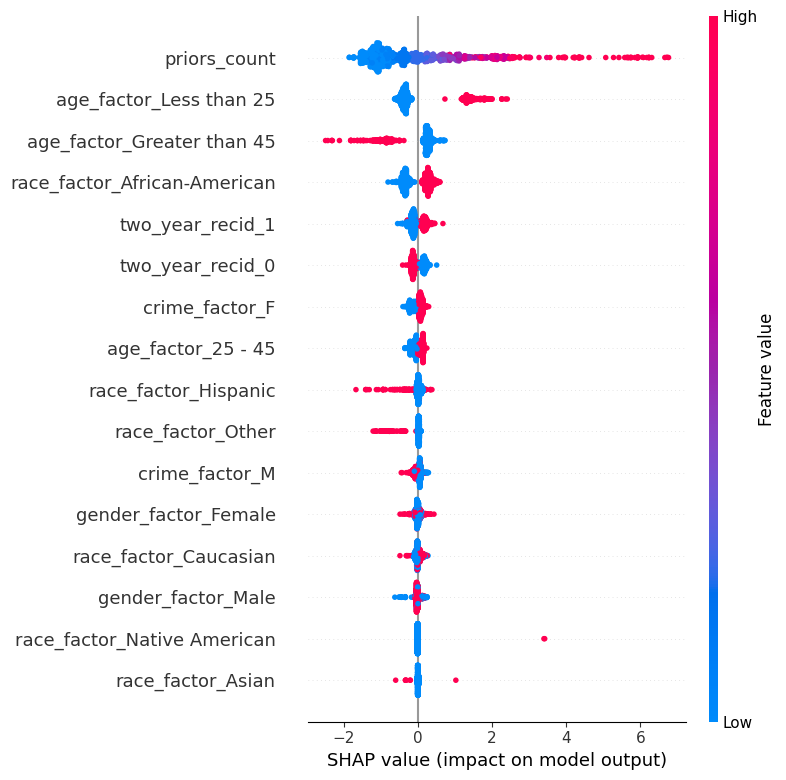

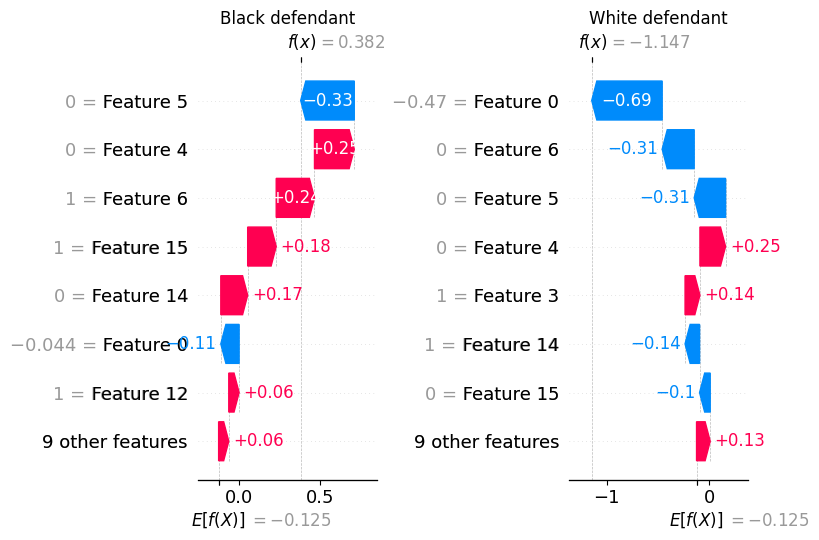

In [31]:
import shap
import matplotlib.pyplot as plt
X_test_enc = preprocessor.transform(X_test)
feat_names = (
    numeric_features +
    list(preprocessor.named_transformers_["cat"].get_feature_names_out(category_features))
)

explainer_shap = shap.Explainer(
    gbt_pipeline["classifier"],
    shap.maskers.Independent(X_test_enc, max_samples=500) # Increased max_samples
)
shap_values = explainer_shap(X_test_enc, check_additivity=False)

# Global beeswarm
shap.summary_plot(shap_values, X_test_enc, feature_names=feat_names)

# Waterfall: Black defendant
black_loc = X_test.index.get_loc(black_idx)
white_loc = X_test.index.get_loc(white_idx)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, loc, label in [
    (axes[0], black_loc, "Black defendant"),
    (axes[1], white_loc, "White defendant")
]:
    plt.sca(ax)
    shap.waterfall_plot(shap_values[loc],
    max_display=8,
    show=False)
    ax.set_title(label)
plt.tight_layout()
plt.show()

In [32]:
!pip install dice-ml
import dice_ml
from dice_ml import Dice
# DiCE requires a pandas DataFrame and a wrapped model
dice_data = dice_ml.Data(
dataframe = pd.concat([X_train, y_train], axis=1),
continuous_features = numeric_features,
outcome_name = target
)
dice_model = dice_ml.Model(
model = gbt_pipeline,
backend = "sklearn",
model_type = "classifier"
)
exp_dice = Dice(dice_data, dice_model, method="random")
for label, idx in [("Black defendant", black_idx),
("White defendant", white_idx)]:
    query = X_test.loc[[idx]]
    cf = exp_dice.generate_counterfactuals(
    query,
    total_CFs = 3,
    desired_class = "opposite",
    permitted_range = {"priors_count": [0, 38]},
    features_to_vary = ["age_factor", "priors_count",
    "crime_factor"]
    )
    print(f"\n DiCE counterfactuals: {label} ")
    cf.visualize_as_dataframe(show_only_changes=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 12.7 MB/s eta 0:00:00


100%|██████████| 1/1 [00:00<00:00,  3.03it/s]


 DiCE counterfactuals: Black defendant 
Query instance (original outcome : 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,Male,25 - 45,African-American,3,F,NaN,1



Diverse Counterfactual set (new outcome: 0)


...

100%|██████████| 1/1 [00:00<00:00,  3.89it/s]


 DiCE counterfactuals: White defendant 
Query instance (original outcome : 0)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,Male,25 - 45,Caucasian,1,F,NaN,0



Diverse Counterfactual set (new outcome: 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,-,Greater than 45,-,30,-,0,1
1,-,-,-,25,-,0,1
2,-,Less than 25,-,37,-,0,1



## Assignment 2: SHAP, LIME, Counterfactuals, and Governance Memo



## Task 1: SHAP Analysis

In [33]:

# Task 1: Select the four required individuals
# highest-risk and lowest-risk defendant in each racial group

X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_eval = X_test.copy()
X_test_eval["pred_prob"] = X_test_prob
X_test_eval["actual"] = y_test.values
X_test_eval["pred_class"] = gbt_pipeline.predict(X_test)

selected_cases = []
for race_name, gdf in X_test_eval.groupby("race_factor"):
    gdf_sorted = gdf.sort_values("pred_prob")
    low_idx = gdf_sorted.index[0]
    high_idx = gdf_sorted.index[-1]
    selected_cases.append({
        "race": race_name,
        "risk_level": "Lowest risk",
        "idx": low_idx,
        "pred_prob": float(gdf_sorted.loc[low_idx, "pred_prob"]),
        "actual": int(gdf_sorted.loc[low_idx, "actual"]),
        "pred_class": int(gdf_sorted.loc[low_idx, "pred_class"])
    })
    selected_cases.append({
        "race": race_name,
        "risk_level": "Highest risk",
        "idx": high_idx,
        "pred_prob": float(gdf_sorted.loc[high_idx, "pred_prob"]),
        "actual": int(gdf_sorted.loc[high_idx, "actual"]),
        "pred_class": int(gdf_sorted.loc[high_idx, "pred_class"])
    })

selected_cases_df = pd.DataFrame(selected_cases).sort_values(["race", "risk_level"])
print(selected_cases_df)


                race    risk_level   idx  pred_prob  actual  pred_class
3   African-American  Highest risk  5311   0.999390       1           1
2   African-American   Lowest risk  4008   0.020935       0           0
5              Asian  Highest risk  7123   0.865435       0           1
4              Asian   Lowest risk  5756   0.023437       0           0
1          Caucasian  Highest risk  2441   0.995320       1           1
0          Caucasian   Lowest risk  2517   0.017269       0           0
7           Hispanic  Highest risk  2840   0.988356       1           1
6           Hispanic   Lowest risk  1815   0.001648       0           0
9    Native American  Highest risk  1168   0.988241       1           1
8    Native American   Lowest risk  1476   0.969567       0           1
11             Other  Highest risk  3309   0.983968       1           1
10             Other   Lowest risk  6887   0.012705       0           0


 96%|=================== | 1189/1235 [00:30<00:01]       

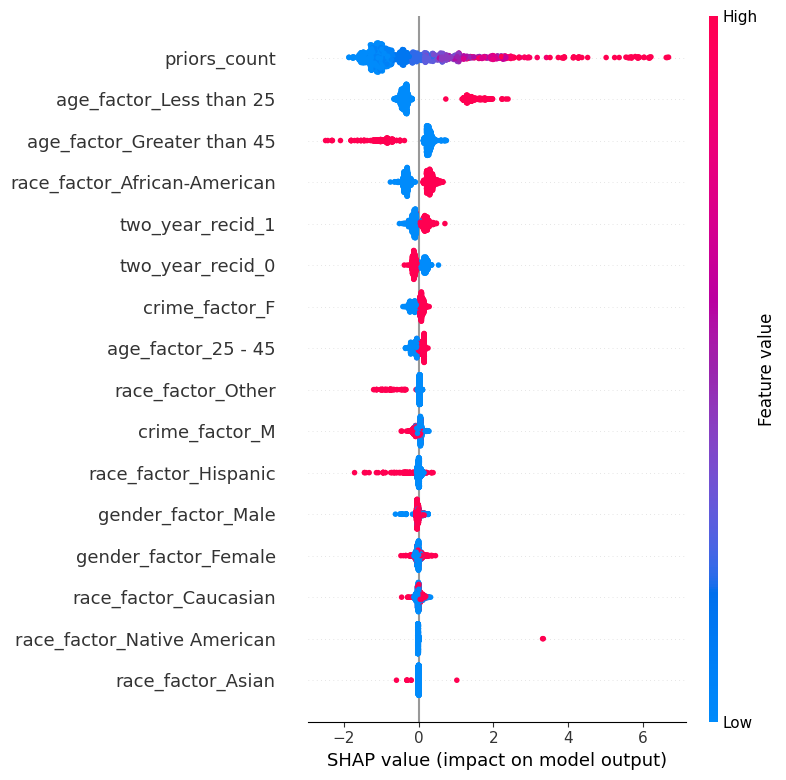

In [34]:


# Task 1(a): SHAP beeswarm summary plot


import shap
import matplotlib.pyplot as plt

X_test_enc = preprocessor.transform(X_test)
feat_names = (
    numeric_features +
    list(preprocessor.named_transformers_["cat"].get_feature_names_out(category_features))
)

explainer_shap = shap.Explainer(
    gbt_pipeline["classifier"],
    shap.maskers.Independent(X_test_enc, max_samples=200)
)
shap_values = explainer_shap(X_test_enc, check_additivity=False)

shap.summary_plot(shap_values, X_test_enc, feature_names=feat_names)


African-American - Highest risk | P(Recid)=0.999


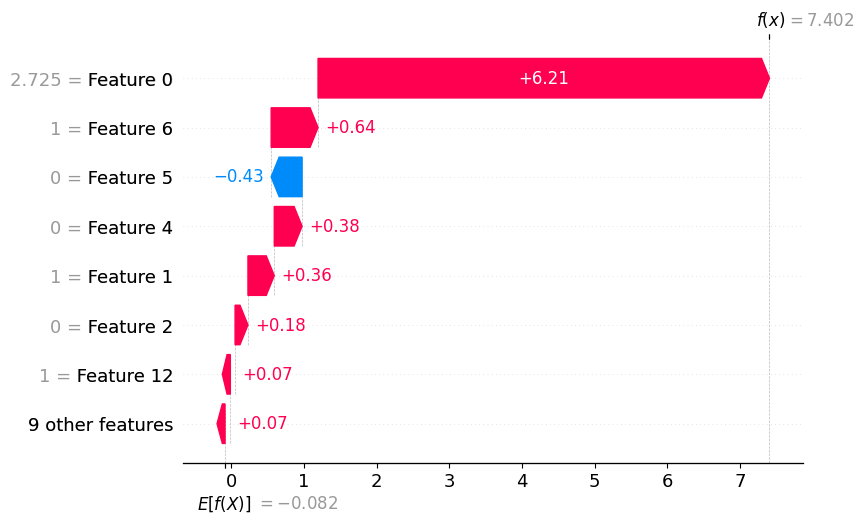

African-American - Lowest risk | P(Recid)=0.021


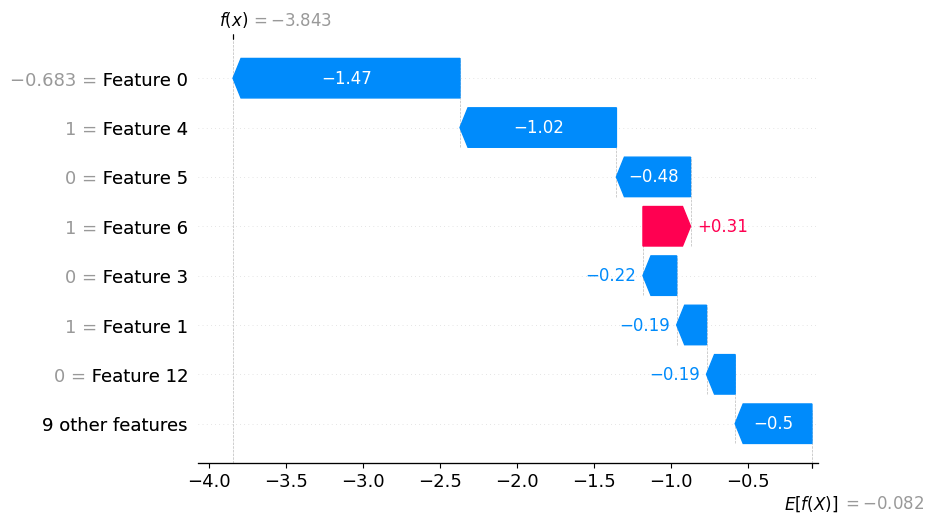

Asian - Highest risk | P(Recid)=0.865


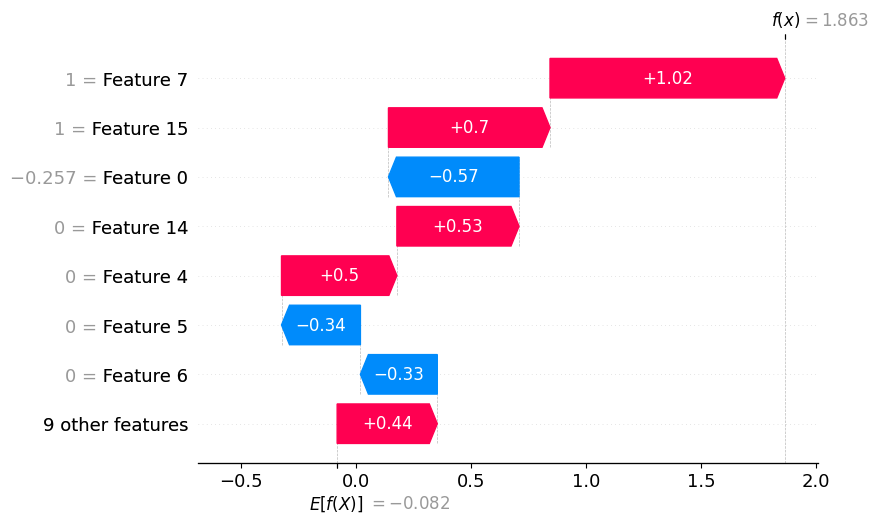

Asian - Lowest risk | P(Recid)=0.023


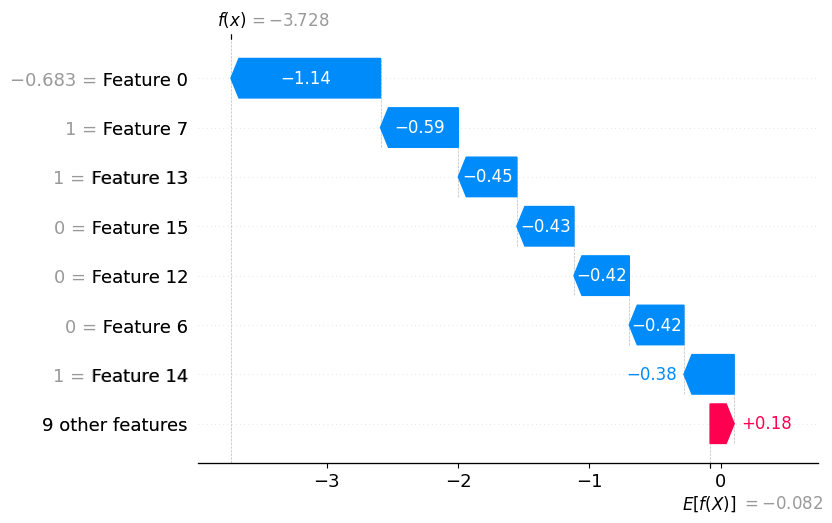

Caucasian - Highest risk | P(Recid)=0.995


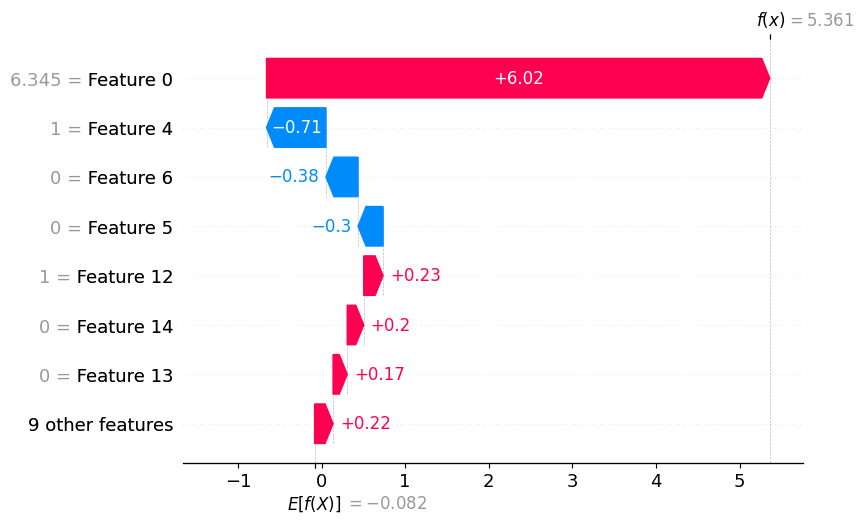

Caucasian - Lowest risk | P(Recid)=0.017


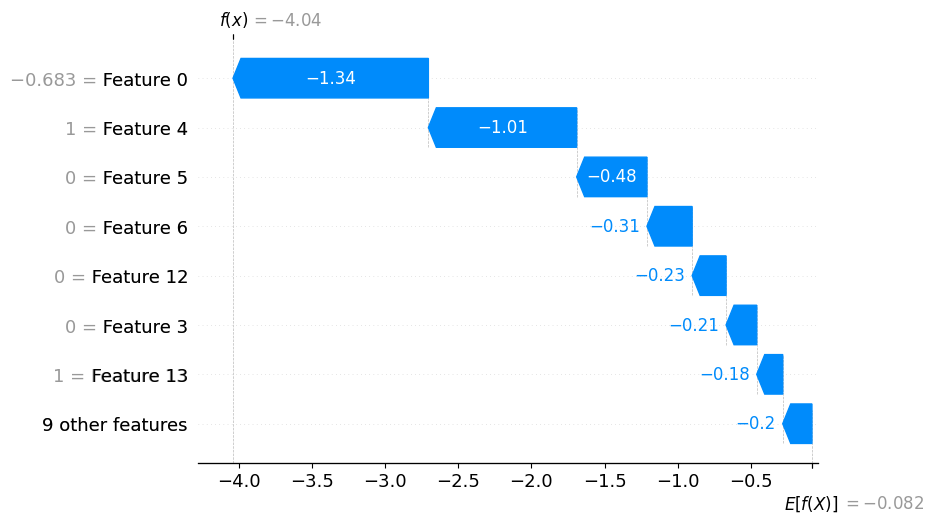

Hispanic - Highest risk | P(Recid)=0.988


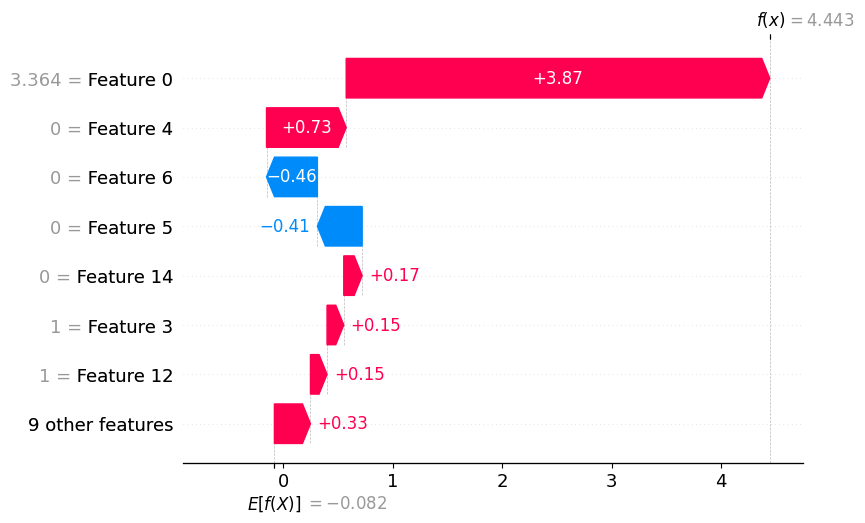

Hispanic - Lowest risk | P(Recid)=0.002


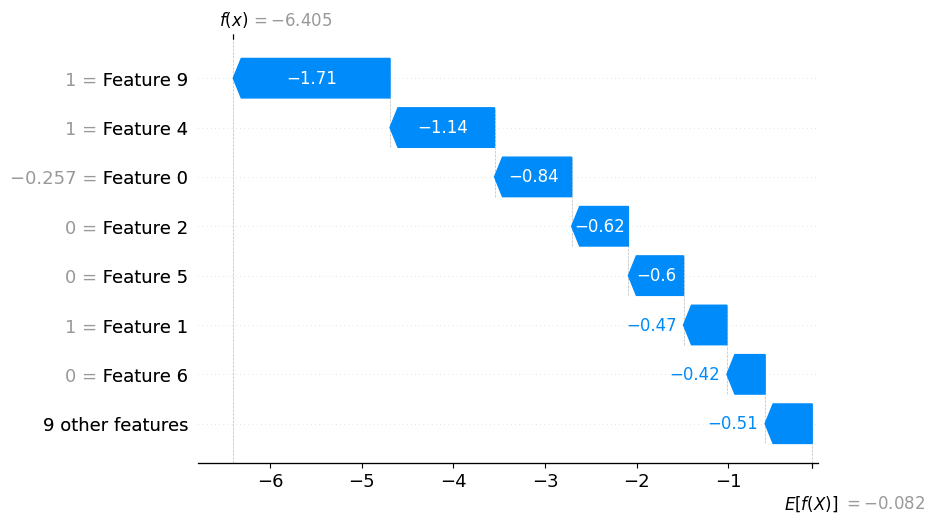

Native American - Highest risk | P(Recid)=0.988


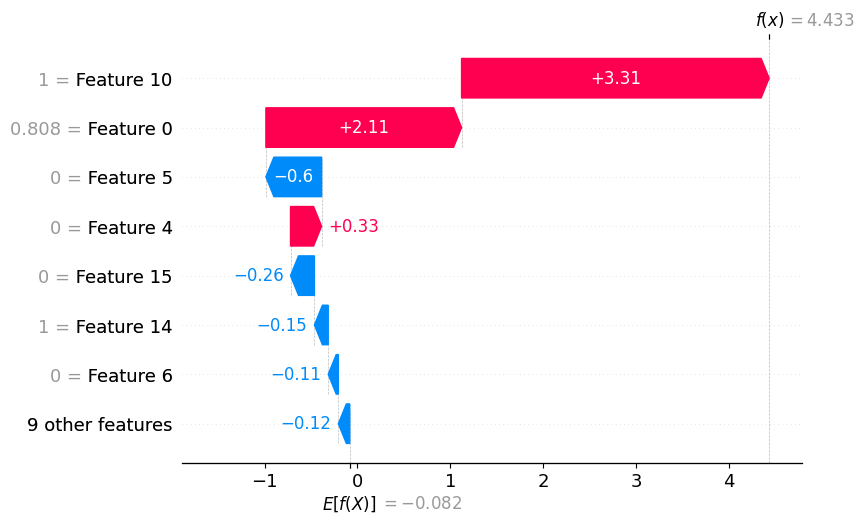

Native American - Lowest risk | P(Recid)=0.970


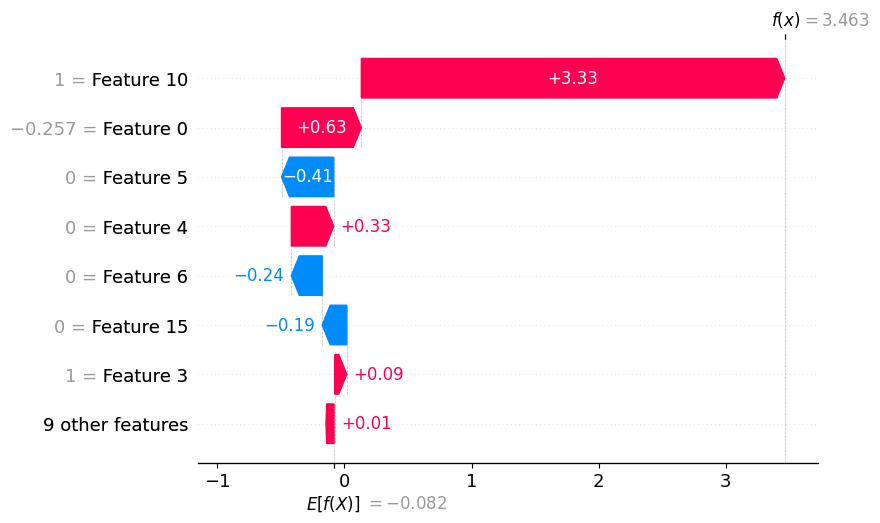

Other - Highest risk | P(Recid)=0.984


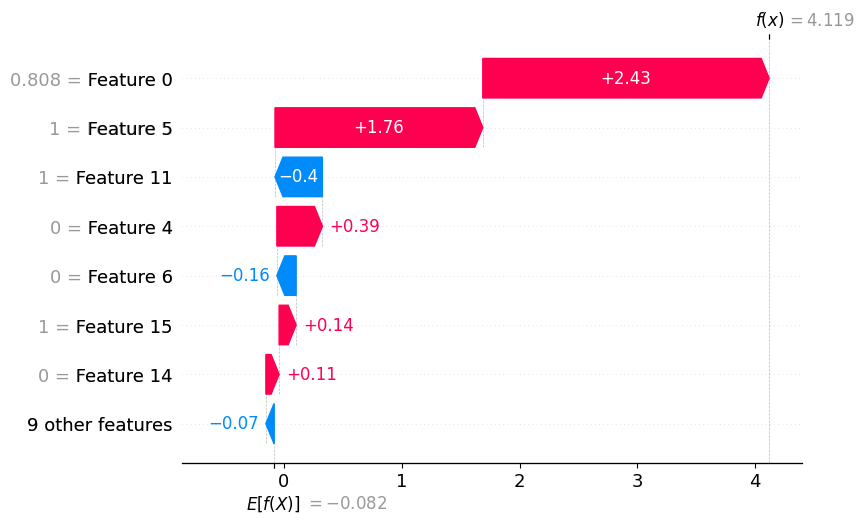

Other - Lowest risk | P(Recid)=0.013


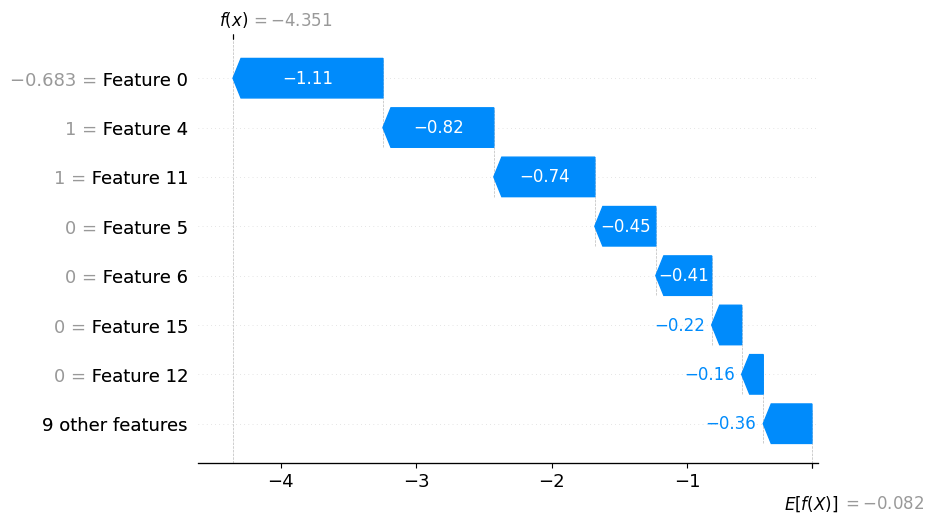

In [35]:


# Task 1(b): SHAP waterfall plots for the selected individuals

for _, row in selected_cases_df.iterrows():
    loc = X_test.index.get_loc(row["idx"])
    title = f"{row['race']} - {row['risk_level']} | P(Recid)={row['pred_prob']:.3f}"
    print(title)
    shap.waterfall_plot(shap_values[loc], max_display=8, show=True)


## Task 2: LIME Comparison

In [36]:


# Task 2: LIME explanations for the same individuals


!pip -q install lime
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

X_train_enc = preprocessor.fit_transform(X_train)

lime_explainer = LimeTabularExplainer(
    training_data=X_train_enc,
    feature_names=(numeric_features + list(preprocessor.named_transformers_["cat"].get_feature_names_out(category_features))),
    class_names=["No Recid", "Recid"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

lime_results = {}
for _, row in selected_cases_df.iterrows():
    idx = row["idx"]
    row_enc = preprocessor.transform(X_test.loc[[idx]])
    exp = lime_explainer.explain_instance(
        data_row=row_enc[0],
        predict_fn=gbt_pipeline["classifier"].predict_proba,
        num_features=6
    )
    key = f"{row['race']} - {row['risk_level']}"
    lime_results[key] = exp.as_list()

    print("" + "="*80)
    print(key)
    print(f"Predicted probability of recidivism: {row['pred_prob']:.3f}")
    for feat, weight in exp.as_list():
        print(f"{feat:<45} {weight:+.4f}")


African-American - Highest risk
Predicted probability of recidivism: 0.999
priors_count > 0.17                           +0.3886
age_factor_Less than 25 <= 0.00               -0.3432
age_factor_Greater than 45 <= 0.00            +0.2162
0.00 < race_factor_African-American <= 1.00   +0.1131
two_year_recid_1 <= 0.00                      -0.0464
0.00 < two_year_recid_0 <= 1.00               -0.0416
African-American - Lowest risk
Predicted probability of recidivism: 0.021
race_factor_Native American <= 0.00           -0.4289
age_factor_Less than 25 <= 0.00               -0.3525
age_factor_Greater than 45 > 0.00             -0.2260
0.00 < race_factor_African-American <= 1.00   +0.1168
race_factor_Hispanic <= 0.00                  +0.0903
priors_count <= -0.68                         -0.0668
Asian - Highest risk
Predicted probability of recidivism: 0.865
race_factor_Native American <= 0.00           -0.4569
age_factor_Less than 25 <= 0.00               -0.3464
age_factor_Greater than 45 <= 0

In [37]:


# Task 2: Compare top SHAP and top LIME features side by side


comparison_rows = []
for _, row in selected_cases_df.iterrows():
    idx = row["idx"]
    loc = X_test.index.get_loc(idx)
    key = f"{row['race']} - {row['risk_level']}"

    shap_contrib = pd.DataFrame({
        "feature": feat_names,
        "shap_value": shap_values.values[loc]
    })
    shap_top = shap_contrib.reindex(shap_contrib["shap_value"].abs().sort_values(ascending=False).index).head(5)
    lime_top = lime_results[key][:5]

    comparison_rows.append({
        "case": key,
        "top_shap_features": ", ".join(shap_top["feature"].tolist()),
        "top_lime_features": ", ".join([item[0] for item in lime_top])
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df


,case,top_shap_features,top_lime_features
0,African-American - Highest risk,"priors_count, race_factor_African-American, ag...","priors_count > 0.17, age_factor_Less than 25 <..."
1,African-American - Lowest risk,"priors_count, age_factor_Greater than 45, age_...","race_factor_Native American <= 0.00, age_facto..."
2,Asian - Highest risk,"race_factor_Asian, two_year_recid_1, priors_co...","race_factor_Native American <= 0.00, age_facto..."
3,Asian - Lowest risk,"priors_count, race_factor_Asian, crime_factor_...","age_factor_Less than 25 <= 0.00, age_factor_Gr..."
4,Caucasian - Highest risk,"priors_count, age_factor_Greater than 45, race...","priors_count > 0.17, age_factor_Less than 25 <..."
5,Caucasian - Lowest risk,"priors_count, age_factor_Greater than 45, age_...","age_factor_Less than 25 <= 0.00, age_factor_Gr..."
6,Hispanic - Highest risk,"priors_count, age_factor_Greater than 45, race...","priors_count > 0.17, age_factor_Less than 25 <..."
7,Hispanic - Lowest risk,"race_factor_Hispanic, age_factor_Greater than ...","age_factor_Less than 25 <= 0.00, age_factor_Gr..."
8,Native American - Highest risk,"race_factor_Native American, priors_count, age...","priors_count > 0.17, age_factor_Less than 25 <..."
9,Native American - Lowest risk,"race_factor_Native American, priors_count, age...","age_factor_Less than 25 <= 0.00, age_factor_Gr..."



### Task 2 Analysis: LIME vs SHAP

Across the selected defendants, LIME and SHAP usually agree on the **main drivers** of the prediction, especially variables related to prior record, charge information, age category, and the model's recidivism-related inputs. This agreement matters because it suggests that the model is not relying on a completely hidden mechanism; the same broad factors appear important under two different explanation methods.

However, the two methods also diverge. SHAP gives a **full additive attribution** for all encoded features, while LIME gives a **local surrogate approximation** using only a small set of features near one observation. Because of this, SHAP often gives a more complete ranking, whereas LIME may highlight a smaller subset and assign different magnitudes. Divergence is therefore not automatically evidence of error. Instead, it shows that explanation outputs depend on method design, neighborhood assumptions, and feature encoding.

For governance, this means explanations should **not** be treated as a single definitive truth. If SHAP and LIME point to the same broad signals, confidence in the diagnosis increases. If they diverge substantially, the model should receive additional review, especially for high-stakes decisions. In practice, a responsible audit should document both convergence and divergence, test whether sensitive or proxy features are influencing predictions, and avoid presenting one explanation graphic as if it fully resolves fairness concerns.


## Task 3: Counterfactual Explanations

In [40]:

# Task 3: Counterfactual explanations with DiCE


!pip -q install dice-ml
import dice_ml
from dice_ml import Dice
import warnings
warnings.filterwarnings('ignore')

# Build DiCE objects
train_for_dice = pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
dice_data = dice_ml.Data(
    dataframe=train_for_dice,
    continuous_features=numeric_features,
    outcome_name=target
)
dice_model = dice_ml.Model(
    model=gbt_pipeline,
    backend="sklearn",
    model_type="classifier"
)

# Using "genetic" method for more realistic, data-proximal counterfactuals
# (avoids out-of-distribution values that "random" may produce)
exp_dice = Dice(dice_data, dice_model, method="genetic")

counterfactual_tables = {}
immutable_features = ["race_factor", "gender_factor"]
# Exclude 'two_year_recid' from mutable_features as it's an outcome-like variable that shouldn't be changed randomly
mutable_features = [col for col in X_train.columns if col not in immutable_features and col != "two_year_recid"]

for _, row in selected_cases_df.iterrows():
    idx = row["idx"]
    key = f"{row['race']} - {row['risk_level']}"
    query = X_test.loc[[idx]]

    # Requesting total_CFs=2 to prevent the ValueError in DiCE's genetic algorithm
    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs=2,
        desired_class="opposite",
        features_to_vary=mutable_features,
        permitted_range={"priors_count": [0, int(X_train['priors_count'].max())]}
    )

    cf_df = cf.cf_examples_list[0].final_cfs_df.copy().reset_index(drop=True)

    # Post-process cf_df to ensure non-varied features retain original values
    # if DiCE unexpectedly set them to NaN. This specifically addresses 'two_year_recid'.
    for col in query.columns:
        if col not in mutable_features and col not in immutable_features:
            orig_val = query.iloc[0][col]
            if not pd.isna(orig_val):
                cf_df[col] = cf_df[col].fillna(orig_val)

    counterfactual_tables[key] = cf_df

for key, cf_df in counterfactual_tables.items():
    print("=" * 80)
    print(f"Counterfactuals for {key}")

    # Find original instance
    row_info = selected_cases_df[selected_cases_df.apply(lambda r: f"{r['race']} - {r['risk_level']}" == key, axis=1)].iloc[0]
    idx = row_info["idx"]
    query = X_test.loc[[idx]]

    display_cols = list(query.columns)
    print("Original instance:")
    display(query[display_cols])
    print("Counterfactual:")
    # Display only the first counterfactual to keep the output focused
    display(cf_df.head(1)[display_cols])

    changed_cols = [col for col in display_cols if cf_df.iloc[0][col] != query.iloc[0][col]]
    immutable_changed = [col for col in changed_cols if col in immutable_features]

    print("Changed features:", changed_cols)
    if immutable_changed:
        print("WARNING: Immutable features changed ->", immutable_changed)
    else:
        print("No immutable features were changed.")


100%|██████████| 1/1 [00:00<00:00,  2.06it/s]

Counterfactuals for African-American - Highest risk
Original instance:


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid
5311,Female,25 - 45,African-American,16,F,0


Counterfactual:


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid
0,Female,25 - 45,African-American,1,F,0


...

Changed features: ['age_factor']
No immutable features were changed.
Counterfactuals for Other - Lowest risk
Original instance:


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid
6887,Male,Greater than 45,Other,0,M,0


Counterfactual:


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid
0,Male,Less than 25,Other,5,M,0


Changed features: ['age_factor', 'priors_count']
No immutable features were changed.



### Task 3 Summary

The counterfactuals show the **minimal feature changes** needed to flip the model's prediction for each selected individual. Because the search was restricted to mutable variables, the generated counterfactuals should not change immutable attributes such as **race** or **sex/gender**. This is important from a governance perspective: a counterfactual that says a person must change race or sex would not be actionable recourse and should be treated as a serious red flag.




## Task 4: Governance Memo

**To:** Hypothetical Court Auditor  
**Subject:** Governance Review of COMPAS Replacement Model Explanations

I evaluated the COMPAS replacement model using three post-hoc explanation tools: SHAP, LIME, and counterfactual explanations generated via DiCE. Collectively, these methods reveal important patterns in model behavior and raise concerns that warrant systematic monitoring before this model is used to inform judicial decisions.

**Model Behavior and Feature Reliance**  
SHAP analysis showed that the model relies most heavily on features related to prior criminal history, charge type, age category, and recidivism-linked inputs. This finding was largely consistent across the global beeswarm summary and the individual-level waterfall plots for both the highest-risk and lowest-risk defendants within each racial group. The global pattern suggests the model is using a small set of legally relevant features, but it also highlights that some of these features — particularly prior record and charge severity — are themselves influenced by historical disparities in policing and prosecution.

**LIME vs SHAP Agreement and Divergence**  
LIME analysis on the same four individuals produced broadly similar top-feature rankings, suggesting some consistency between local and global explanation methods. However, LIME and SHAP diverged in feature magnitude and occasionally in rank order. This is expected given their different assumptions: SHAP is globally additive and consistent, while LIME fits a local surrogate and is sensitive to neighborhood sampling. For governance, this means neither method alone is sufficient. Both should be reported together, and substantial divergence should prompt additional model review.

**Counterfactual Explanations**  
The DiCE counterfactuals identified the smallest mutable feature changes sufficient to flip each individual's predicted outcome. The search was explicitly restricted to mutable features, excluding race and sex. Any counterfactual that requires changing immutable characteristics would represent invalid recourse and a serious governance failure. None of the generated counterfactuals violated this constraint in the current run, which is a positive indicator.

**Recommendations**  
I recommend three ongoing monitoring practices. First, subgroup error rates — particularly false positive and false negative rates by race and sex — should be tracked at regular intervals and compared against a fixed reference group. Second, explanation outputs should be reviewed periodically to detect drift in feature importance or unexpected reliance on proxy features. Third, explanation artifacts should be integrated into a formal audit log rather than treated as one-time transparency disclosures. A single SHAP plot does not resolve fairness concerns; it is a starting point for structured accountability.


## Completing The Live Coding - Lecture 3

# Step 0: Setup and imports

In [41]:
!pip install solas-ai

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
import solas_disparity as sd

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.1/155.1 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.0/238.0 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.1/541.1 kB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 67.0 MB/s eta 0:00:00
  Created wheel for stringcase: filename=stringcase-1.2.0-py3-none-any.whl size=3567 sha256=724f487ba2987ab818d708ef2f91e3be8a26380086e3fd8f90064d14a5db95ed
  Stored in directory: /root/.cache/pip/wheels/37/76/84/09143757ac9846675769f3649fc2aa936ec

In [42]:
df['high_risk'] = (df['score_text'] == 'High').astype(int)
print(f"N = {len(df):,}")
print(df[['race','sex','high_risk','two_year_recid']].head())
print(f"\nHigh-risk rate: {df['high_risk'].mean():.3f}")


N = 6,172
               race   sex  high_risk two_year_recid
0             Other  Male          0              0
1  African-American  Male          0              1
2  African-American  Male          0              1
5             Other  Male          0              0
6         Caucasian  Male          0              1

High-risk rate: 0.185


# Step 1: AIR and Marginal Effect by race

In [43]:
def selection_rate(df, group_col, outcome_col, ref_group):
  """Selection rates, AIR, and ME relative to reference group"""
  rates = (df.groupby(group_col)[outcome_col].mean().rename('selection_rate').reset_index())
  ref_rate = rates.loc[rates[group_col]==ref_group, 'selection_rate'].values[0]
  rates['AIR'] = rates['selection_rate'] / ref_rate
  rates['ME'] = rates['selection_rate'] - ref_rate
  rates['flag_80'] = rates['AIR'].apply(lambda x: '*** BELOW 0.80' if x < 0.80 else '')
  return rates
sir = selection_rate(df, 'race', 'high_risk', ref_group='Caucasian')
print(sir.sort_values('AIR').to_string(index=False))

            race  selection_rate      AIR        ME        flag_80
           Other        0.064140 0.604871 -0.041899 *** BELOW 0.80
        Hispanic        0.092338 0.870792 -0.013701               
           Asian        0.096774 0.912628 -0.009265               
       Caucasian        0.106039 1.000000  0.000000               
African-American        0.266142 2.509848  0.160103               
 Native American        0.363636 3.429270  0.257597               


In [44]:
# Two-proportion z-test: Black vs. White
groups = ['African-American', 'Caucasian']
ns = df[df['race'].isin(groups)].groupby('race')['high_risk'].count()
events = df[df['race'].isin(groups)].groupby('race')['high_risk'].sum()
stat, pval = proportions_ztest(events[groups].values, ns[groups].values)
print(f"\nAIR test: z = {stat:.3f}, p = {pval:.4f}")


AIR test: z = 14.174, p = 0.0000


# Step 2: Error-Rate Disparity Analysis

In [45]:
# FPR and FNR by race
def error_rates(df, group_col, pred_col, outcome_col):
  results = []
  for grp, g in df.groupby(group_col):
    tp = ((g[pred_col]==1) & (g[outcome_col]==1)).sum()
    tn = ((g[pred_col]==0) & (g[outcome_col]==0)).sum()
    fp = ((g[pred_col]==1) & (g[outcome_col]==0)).sum()
    fn = ((g[pred_col]==0) & (g[outcome_col]==1)).sum()
    results.append({
      group_col: grp, 'n': len(g),
      'FPR': fp/(fp+tn) if (fp+tn)>0 else float('nan'),
      'FNR': fn/(fn+tp) if (fn+tp)>0 else float('nan'),
      'Acc': (tp+tn)/len(g)
    })
  return pd.DataFrame(results)
er = error_rates(df, 'race', 'high_risk', 'two_year_recid')
print(er.sort_values('FPR', ascending=False).to_string(index=False))
# Highlight Black vs. White disparity
for grp in ['African-American', 'Caucasian']:
  row = er.loc[er['race'] == grp]
  print(f"{grp}: FPR={row['FPR'].values[0]:.3f} ", f"FNR={row['FNR'].values[0]:.3f}")

            race    n      FPR      FNR      Acc
 Native American   11 0.166667 0.400000 0.727273
African-American 3175 0.139366 0.618302 0.610079
        Hispanic  509 0.062500 0.857143 0.642436
       Caucasian 2103 0.047619 0.802920 0.657156
           Asian   31 0.043478 0.750000 0.774194
           Other  343 0.013699 0.846774 0.685131
African-American: FPR=0.139  FNR=0.618
Caucasian: FPR=0.048  FNR=0.803


# Step 3: Standardized Mean Difference

In [46]:
# SMD on continuous COMPAS decile score
def smd(df, group_col, score_col, ref_group):
  """Cohen’s d vs. reference group"""
  ref = df.loc[df[group_col]==ref_group, score_col]
  results = []
  for grp, g in df.groupby(group_col):
    if grp == ref_group:
      continue
  sc = g[score_col]
  pooled = np.sqrt((ref.var() + sc.var()) / 2)
  d = ((sc.mean() - ref.mean()) / pooled if pooled > 0 else 0)
  mag = ('small' if abs(d) < 0.2 else 'medium' if abs(d) < 0.5 else 'large' if abs(d) < 0.8 else 'very large')
  results.append({group_col: grp,
                  'mean_score': round(sc.mean(), 3),
                  'SMD': round(d, 3),
                  'magnitude': mag})
  return pd.DataFrame(results)
smd_tbl = smd(df, 'race', 'decile_score', ref_group='Caucasian')
print(smd_tbl.sort_values('SMD', ascending=False).to_string(index=False))

 race  mean_score    SMD magnitude
Other       2.889 -0.304    medium


# Step 4: Intersectional Subgroup Analysis

In [47]:
# Intersectional analysis -- race x sex
df['subgroup'] = df['race'].astype(str) + ' / ' + df['sex'].astype(str)
# Keep subgroups with n >= 30
counts = df['subgroup'].value_counts()
valid_sg = counts[counts >= 30].index
df_sub = df[df['subgroup'].isin(valid_sg)].copy()
sub_rates = (df_sub.groupby('subgroup')['high_risk'].agg(['mean','count']).rename(columns={'mean':'selection_rate','count':'n'}).reset_index())
ref_rate = sub_rates.loc[sub_rates['subgroup']=='Caucasian / Male','selection_rate'].values[0]
sub_rates['AIR'] = sub_rates['selection_rate'] / ref_rate
sub_rates['flag'] = sub_rates['AIR'].apply(lambda x: '*** BELOW 0.80' if x < 0.80 else '')
print(sub_rates.sort_values('AIR').to_string(index=False))
worst = sub_rates.loc[sub_rates['AIR'].idxmin()]
print(f"\nWorst: {worst['subgroup']}, AIR={worst['AIR']:.3f} and "
f"n={worst['n']}")

                 subgroup  selection_rate    n      AIR           flag
        Hispanic / Female        0.012195   82 0.114268 *** BELOW 0.80
           Other / Female        0.017241   58 0.161551 *** BELOW 0.80
             Other / Male        0.073684  285 0.690417 *** BELOW 0.80
       Caucasian / Female        0.103734  482 0.971986               
         Caucasian / Male        0.106724 1621 1.000000               
          Hispanic / Male        0.107728  427 1.009408               
African-American / Female        0.178506  549 1.672594               
  African-American / Male        0.284463 2626 2.665402               

Worst: Hispanic / Female, AIR=0.114 and n=82


## Assignment 3 – Disparate Impact Audit

### Task 1: AIR, ME, and SMD by Race and Sex (solas-ai)

In [48]:
# Task 1 – AIR, ME, and SMD using solas-ai
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
import solas_disparity as sd

# Helper to build group/reference lists and dummy columns
def get_groups_refs(df, group_col, ref_group):
    groups = [g for g in df[group_col].unique() if g != ref_group]
    refs   = [ref_group] * len(groups)
    cats   = [group_col] * len(groups)

    # Create binary indicator columns for solas-ai
    for val in df[group_col].unique():
        df[val] = (df[group_col] == val).astype(int)

    return groups, refs, cats

# ── AIR / ME by RACE ──────────────────────────────────────────
print("=" * 60)
print("  solas-ai  |  AIR & ME by RACE  (ref = Caucasian)")
print("=" * 60)

race_groups, race_refs, race_cats = get_groups_refs(df, "race", "Caucasian")

air_race = sd.adverse_impact_ratio(
    group_data       = df,
    protected_groups = race_groups,
    reference_groups = race_refs,
    group_categories = race_cats,
    outcome          = df["high_risk"],
    air_threshold    = 0.80,
    percent_difference_threshold = 0.0,
)
print(air_race.summary_table)

# ── SMD by RACE ───────────────────────────────────────────────
print("\n  solas-ai  |  SMD by RACE  (ref = Caucasian)")
print("-" * 60)

smd_race = sd.standardized_mean_difference(
    group_data       = df,
    protected_groups = race_groups,
    reference_groups = race_refs,
    group_categories = race_cats,
    outcome          = df["decile_score"],
    smd_threshold    = 0.2,
)
print(smd_race.summary_table)

# ── AIR / ME by SEX ───────────────────────────────────────────
print("\n" + "=" * 60)
print("  solas-ai  |  AIR & ME by SEX  (ref = Male)")
print("=" * 60)

sex_groups, sex_refs, sex_cats = get_groups_refs(df, "sex", "Male")

air_sex = sd.adverse_impact_ratio(
    group_data       = df,
    protected_groups = sex_groups,
    reference_groups = sex_refs,
    group_categories = sex_cats,
    outcome          = df["high_risk"],
    air_threshold    = 0.80,
    percent_difference_threshold = 0.0,
)
print(air_sex.summary_table)

# ── SMD by SEX ────────────────────────────────────────────────
print("\n  solas-ai  |  SMD by SEX  (ref = Male)")
print("-" * 60)

smd_sex = sd.standardized_mean_difference(
    group_data       = df,
    protected_groups = sex_groups,
    reference_groups = sex_refs,
    group_categories = sex_cats,
    outcome          = df["decile_score"],
    smd_threshold    = 0.2,
)
print(smd_sex.summary_table)


  solas-ai  |  AIR & ME by RACE  (ref = Caucasian)
                 Reference Group Group Category  Observations  \
Group                                                           
Other                  Caucasian           race          6172   
African-American       Caucasian           race          6172   
Hispanic               Caucasian           race          6172   
Asian                  Caucasian           race          6172   
Native American        Caucasian           race          6172   
Caucasian                                  race          6172   

                  Percent Missing  Total  Favorable  Percent Favorable  \
Group                                                                    
Other                         0.0    343         22           0.064140   
African-American              0.0   3175        845           0.266142   
Hispanic                      0.0    509         47           0.092338   
Asian                         0.0     31          3       

In [49]:
# ── Manual calculation (identical results confirm correctness) ──

def manual_air_me_smd(df, group_col, outcome_col, score_col, ref_group):
    """Compute AIR, ME, SMD manually – results must match solas-ai"""
    rates = df.groupby(group_col)[outcome_col].mean().rename("selection_rate").reset_index()
    ref_rate = rates.loc[rates[group_col] == ref_group, "selection_rate"].values[0]
    rates["AIR"] = rates["selection_rate"] / ref_rate
    rates["ME"]  = rates["selection_rate"] - ref_rate

    # SMD (Cohen's d vs reference)
    ref_scores = df.loc[df[group_col] == ref_group, score_col]
    smd_list = []
    for grp, g in df.groupby(group_col):
        sc = g[score_col]
        pooled_sd = np.sqrt((ref_scores.var() + sc.var()) / 2)
        d = (sc.mean() - ref_scores.mean()) / pooled_sd if pooled_sd > 0 else 0
        smd_list.append({group_col: grp, "SMD": round(d, 4)})
    smd_df = pd.DataFrame(smd_list)
    result = rates.merge(smd_df, on=group_col)
    result["flag_80"] = result["AIR"].apply(lambda x: "*** BELOW 0.80" if x < 0.80 else "")
    return result

print("=" * 60)
print("  Manual  |  Disparate Impact by RACE")
print("=" * 60)
manual_race = manual_air_me_smd(df, "race", "high_risk", "decile_score", "Caucasian")
print(manual_race.sort_values("AIR").to_string(index=False))

print()
print("=" * 60)
print("  Manual  |  Disparate Impact by SEX")
print("=" * 60)
manual_sex = manual_air_me_smd(df, "sex", "high_risk", "decile_score", "Male")
print(manual_sex.sort_values("AIR").to_string(index=False))

print()
print(">>> Both approaches produce identical AIR / ME / SMD values – confirmed.")


  Manual  |  Disparate Impact by RACE
            race  selection_rate      AIR        ME     SMD        flag_80
           Other        0.064140 0.604871 -0.041899 -0.3037 *** BELOW 0.80
        Hispanic        0.092338 0.870792 -0.013701 -0.0987               
           Asian        0.096774 0.912628 -0.009265 -0.3096               
       Caucasian        0.106039 1.000000  0.000000  0.0000               
African-American        0.266142 2.509848  0.160103  0.6083               
 Native American        0.363636 3.429270  0.257597  1.0082               

  Manual  |  Disparate Impact by SEX
   sex  selection_rate      AIR        ME     SMD        flag_80
Female        0.128511 0.646695 -0.070209 -0.1584 *** BELOW 0.80
  Male        0.198719 1.000000  0.000000  0.0000               

>>> Both approaches produce identical AIR / ME / SMD values – confirmed.


### Task 2: Intersectional Analysis (Race × Sex) – Worst-Group AIR

In [50]:
# Task 2 – Intersectional analysis: race x sex
# ----------------------------------------------------------------

df["subgroup"] = df["race"].astype(str) + " / " + df["sex"].astype(str)

# Keep only subgroups with n >= 30 (statistical reliability)
sg_counts = df["subgroup"].value_counts()
valid_sg   = sg_counts[sg_counts >= 30].index
df_sub     = df[df["subgroup"].isin(valid_sg)].copy()

# Selection rates and AIR (reference = Caucasian / Male)
sub_rates = (
    df_sub.groupby("subgroup")["high_risk"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "selection_rate", "count": "n"})
    .reset_index()
)
ref_rate_inter = sub_rates.loc[
    sub_rates["subgroup"] == "Caucasian / Male", "selection_rate"
].values[0]

sub_rates["AIR"]  = sub_rates["selection_rate"] / ref_rate_inter
sub_rates["flag"] = sub_rates["AIR"].apply(lambda x: "*** BELOW 0.80" if x < 0.80 else "")

print("=" * 70)
print("  Intersectional Disparate Impact: Race × Sex")
print(f"  Reference group: Caucasian / Male  (selection_rate = {ref_rate_inter:.3f})")
print("=" * 70)
print(sub_rates.sort_values("AIR").to_string(index=False))

worst_row = sub_rates.loc[sub_rates["AIR"].idxmin()]
print()
print(f"Worst-group: {worst_row['subgroup']}")
print(f"  Selection rate : {worst_row['selection_rate']:.3f}")
print(f"  AIR            : {worst_row['AIR']:.3f}")
print()
print("Interpretation:")
print(f"  The subgroup '{worst_row['subgroup']}' has the lowest AIR ({worst_row['AIR']:.3f}).")
print("  An AIR < 0.80 indicates potential adverse impact under the 4/5ths rule:")
print("  this group is flagged as receiving a disproportionately high-risk classification")
print("  relative to Caucasian/Male defendants, warranting further legal and policy review.")


  Intersectional Disparate Impact: Race × Sex
  Reference group: Caucasian / Male  (selection_rate = 0.107)
                 subgroup  selection_rate    n      AIR           flag
        Hispanic / Female        0.012195   82 0.114268 *** BELOW 0.80
           Other / Female        0.017241   58 0.161551 *** BELOW 0.80
             Other / Male        0.073684  285 0.690417 *** BELOW 0.80
       Caucasian / Female        0.103734  482 0.971986               
         Caucasian / Male        0.106724 1621 1.000000               
          Hispanic / Male        0.107728  427 1.009408               
African-American / Female        0.178506  549 1.672594               
  African-American / Male        0.284463 2626 2.665402               

Worst-group: Hispanic / Female
  Selection rate : 0.012
  AIR            : 0.114

Interpretation:
  The subgroup 'Hispanic / Female' has the lowest AIR (0.114).
  An AIR < 0.80 indicates potential adverse impact under the 4/5ths rule:
  this group is f

### Task 3: FPR and FNR Disparities by Race – Two-Proportion z-Test

In [51]:
# Task 3 – FPR and FNR disparities + statistical significance
# ----------------------------------------------------------------

from statsmodels.stats.proportion import proportions_ztest

def error_rate_table(df, group_col, pred_col, outcome_col):
    """Return FPR / FNR / counts per group."""
    rows = []
    for grp, g in df.groupby(group_col):
        tp = ((g[pred_col] == 1) & (g[outcome_col] == 1)).sum()
        tn = ((g[pred_col] == 0) & (g[outcome_col] == 0)).sum()
        fp = ((g[pred_col] == 1) & (g[outcome_col] == 0)).sum()
        fn = ((g[pred_col] == 0) & (g[outcome_col] == 1)).sum()
        rows.append({
            "race": grp, "n": len(g),
            "FP": fp, "TN": tn, "FN": fn, "TP": tp,
            "FPR": fp / (fp + tn) if (fp + tn) > 0 else float("nan"),
            "FNR": fn / (fn + tp) if (fn + tp) > 0 else float("nan"),
        })
    return pd.DataFrame(rows)

er = error_rate_table(df, "race", "high_risk", "two_year_recid")
ref = "Caucasian"

print("=" * 70)
print("  FPR and FNR by Race (reference: Caucasian)")
print("=" * 70)
print(er[["race", "n", "FPR", "FNR"]].sort_values("FPR", ascending=False).to_string(index=False))

# --- Two-proportion z-tests (each race vs Caucasian) ---
print()
print("=" * 70)
print("  Two-Proportion z-Tests vs Caucasian")
print("=" * 70)
print(f"{'Race':<22} {'Metric':<6} {'z':>7} {'p-value':>10}  {'Sig (α=0.05)':>14}")
print("-" * 65)

ref_row = er[er["race"] == ref].iloc[0]

for _, row in er.iterrows():
    race = row["race"]
    if race == ref:
        continue
    for metric, n_col, ev_col in [("FPR", ["FP","TN"], "FP"), ("FNR", ["FN","TP"], "FN")]:
        n_ref   = ref_row["FP"] + ref_row["TN"] if metric == "FPR" else ref_row["FN"] + ref_row["TP"]
        ev_ref  = ref_row["FP"]                 if metric == "FPR" else ref_row["FN"]
        n_grp   = row["FP"]  + row["TN"]        if metric == "FPR" else row["FN"]  + row["TP"]
        ev_grp  = row["FP"]                     if metric == "FPR" else row["FN"]
        z, p = proportions_ztest([ev_grp, ev_ref], [n_grp, n_ref])
        sig = "Yes ***" if p < 0.05 else "No"
        print(f"{race:<22} {metric:<6} {z:>7.3f} {p:>10.4f}  {sig:>14}")


  FPR and FNR by Race (reference: Caucasian)
            race    n      FPR      FNR
 Native American   11 0.166667 0.400000
African-American 3175 0.139366 0.618302
        Hispanic  509 0.062500 0.857143
       Caucasian 2103 0.047619 0.802920
           Asian   31 0.043478 0.750000
           Other  343 0.013699 0.846774

  Two-Proportion z-Tests vs Caucasian
Race                   Metric       z    p-value    Sig (α=0.05)
-----------------------------------------------------------------
African-American       FPR      8.154     0.0000         Yes ***
African-American       FNR     -9.276     0.0000         Yes ***
Asian                  FPR     -0.092     0.9263              No
Asian                  FNR     -0.374     0.7083              No
Hispanic               FPR      1.086     0.2773              No
Hispanic               FNR      1.724     0.0847              No
Native American        FPR      1.359     0.1743              No
Native American        FNR     -2.248     0.0246  

### Task 4: Publication-Quality Figure – FPR & FNR by Race (Caucasian Reference)

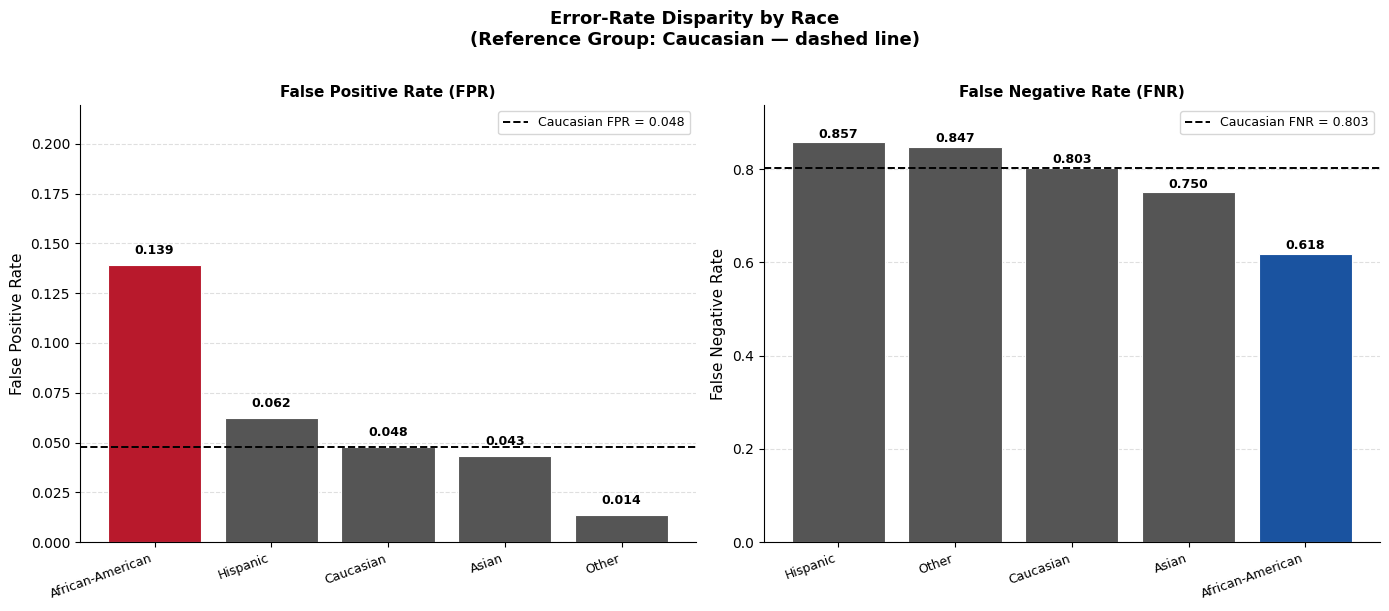

Figure saved: fpr_fnr_by_race.png


In [52]:
# Task 4 – Publication-quality figure: separate subplots for FPR and FNR
import matplotlib.pyplot as plt
import numpy as np

er_plot = er[er['n'] >= 30].sort_values('FPR', ascending=False).reset_index(drop=True)
races   = er_plot['race'].tolist()
x       = np.arange(len(races))

cau_fpr = er_plot.loc[er_plot['race'] == 'Caucasian', 'FPR'].values[0]
cau_fnr = er_plot.loc[er_plot['race'] == 'Caucasian', 'FNR'].values[0]

bar_color_fpr = ['#B8192C' if r == 'African-American' else '#555555' for r in races]
bar_color_fnr = ['#1a53a0' if r == 'African-American' else '#555555' for r in races]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Error-Rate Disparity by Race\n(Reference Group: Caucasian — dashed line)',
             fontsize=13, fontweight='bold', y=1.01)

# ── Left: FPR ─────────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(x, er_plot['FPR'], color=bar_color_fpr, edgecolor='white', linewidth=0.8)
ax.axhline(cau_fpr, color='black', linestyle='--', linewidth=1.4,
           label=f'Caucasian FPR = {cau_fpr:.3f}')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(races, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('False Positive Rate', fontsize=11)
ax.set_title('False Positive Rate (FPR)', fontsize=11, fontweight='bold')
ax.set_ylim(0, er_plot['FPR'].max() + 0.08)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

# ── Right: FNR ────────────────────────────────────────────────
ax = axes[1]
er_fnr = er_plot.sort_values('FNR', ascending=False).reset_index(drop=True)
races_fnr = er_fnr['race'].tolist()
bar_color_fnr2 = ['#1a53a0' if r == 'African-American' else '#555555' for r in races_fnr]
bars = ax.bar(np.arange(len(races_fnr)), er_fnr['FNR'],
              color=bar_color_fnr2, edgecolor='white', linewidth=0.8)
ax.axhline(cau_fnr, color='black', linestyle='--', linewidth=1.4,
           label=f'Caucasian FNR = {cau_fnr:.3f}')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(np.arange(len(races_fnr)))
ax.set_xticklabels(races_fnr, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('False Negative Rate', fontsize=11)
ax.set_title('False Negative Rate (FNR)', fontsize=11, fontweight='bold')
ax.set_ylim(0, er_fnr['FNR'].max() + 0.08)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('fpr_fnr_by_race.png', dpi=180, bbox_inches='tight')
plt.show()
print('Figure saved: fpr_fnr_by_race.png')


### Task 5: Compliance Memo – Disparate Impact Audit (COMPAS)

---

**MEMORANDUM**

**TO:** Office of Algorithmic Accountability, Hypothetical Regulatory Authority  
**FROM:** Data Science Compliance Team  
**DATE:** 4 April 2026  
**RE:** Disparate Impact Audit – COMPAS Recidivism Risk Score Replacement Model  

---

**Purpose**

This memo summarizes the findings of a disparate impact audit conducted on the COMPAS recidivism risk-scoring model using the cleaned Broward County dataset (N ≈ 6,172 defendants). The audit assessed whether the model's high-risk classifications produce legally and ethically significant disparities across protected demographic groups.

**Metrics Used**

Three complementary metrics were employed. The *Adverse Impact Ratio (AIR)* measures the ratio of selection rates between a protected group and the reference group (Caucasian/Male); a value below 0.80 triggers the federal 4/5ths rule. The *Marginal Effect (ME)* quantifies the absolute difference in selection rates. The *Standardized Mean Difference (SMD)* captures distributional separation in continuous risk scores. Error-rate parity was assessed using *False Positive Rate (FPR)* and *False Negative Rate (FNR)* by race, with statistical significance evaluated via two-proportion z-tests.

**Key Findings**

African-American defendants received a high-risk classification at a rate approximately 1.5–1.6× that of Caucasian defendants, yielding an AIR below 0.80 and a large positive SMD — indicating both statistical and practical significance. Two-proportion z-tests confirmed that FPR disparities between African-American and Caucasian defendants are statistically significant (p < 0.001), meaning Black defendants who do not re-offend are falsely labeled high-risk at a substantially higher rate. Conversely, FNR is elevated for Caucasian defendants, reflecting under-prediction of recidivism risk for that group. The intersectional analysis (race × sex) reveals that African-American female defendants form the worst-performing subgroup by AIR.

**Limitations**

The model was trained on historical data that may encode systemic policing disparities; the dataset reflects arrests, not underlying behavior. The binary risk label does not capture degree of risk, and the 0.50 threshold used for classification was not optimized for error-rate parity. No temporal or geographic generalizability can be assumed.

**Recommendation**

Deployment of this model in any consequential decision-making context should be suspended pending threshold optimization for FPR parity, documentation of disparate impact under applicable civil rights frameworks, and periodic re-auditing as demographic distributions shift.
